In [4]:
!pip -q install tensorflow-datasets

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [3]:
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    "oxford_flowers102",
    split=["train", "validation", "test"],
    as_supervised=True,   # (image, label) 형태로
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.1AJKSM_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.1AJKSM_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


In [5]:
print("num_classes:", ds_info.features["label"].num_classes)
label_names = ds_info.features["label"].names
print("example label names:", label_names[:5])

num_classes: 102
example label names: ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold']


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# EfficientNet 전용 전처리 (ImageNet pretrained 기준)
preprocess = tf.keras.applications.efficientnet.preprocess_input

# 데이터 증강
data_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="augment")

def train_map_fn(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = data_augment(image)
    image = preprocess(image)
    return image, label

def test_map_fn(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess(image)
    return image, label

train_ds = (ds_train
            .shuffle(2048)
            .map(train_map_fn, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds = (ds_val
          .map(test_map_fn, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

test_ds = (ds_test
           .map(test_map_fn, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))


In [7]:
NUM_CLASSES = ds_info.features["label"].num_classes

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False  # 1단계: feature extractor로만 사용

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)  # BN 안정성 위해 False 권장
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,180,233 (15.95 MB)

 Trainable params: 130,662 (510.40 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.2)
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.0356 - loss: 4.6398 - val_accuracy: 0.4020 - val_loss: 3.6367 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 419ms/step - accuracy: 0.4235 - loss: 3.3599 - val_accuracy: 0.6235 - val_loss: 2.7806 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 367ms/step - accuracy: 0.6556 - loss: 2.5111 - val_accuracy: 0.7157 - val_loss: 2.2044 - learning_rate: 0.0010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 367ms/step - accuracy: 0.8114 - loss: 1.9007 - val_accuracy: 0.7549 - val_loss: 1.8140 - learning_rate: 0.0010
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 364ms/step - accuracy: 0.8569 - loss: 1.5115 - val_accuracy: 0.7647 - val_loss: 1.5541 - learning_rate: 0.0010
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 366ms/step - accuracy: 0.8937 - loss: 1.1842 - val_accuracy: 0.7951 - val_loss: 1.3733 - learning_rate: 0.0010
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 372ms/step - accuracy: 0.9355 - loss: 0.984

In [9]:
# 2단계: 일부 레이어만 학습 가능하게
base.trainable = True

# BatchNorm은 보통 고정하는 게 안정적
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# 너무 많이 풀면 불안정 -> 보통 뒤쪽만 학습
fine_tune_at = int(len(base.layers) * 0.7)  # 뒤 30%만 train
for layer in base.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9630 - loss: 0.4975 - val_accuracy: 0.8304 - val_loss: 0.8317 - learning_rate: 1.0000e-05
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 369ms/step - accuracy: 0.9527 - loss: 0.3759 - val_accuracy: 0.8324 - val_loss: 0.7723 - learning_rate: 1.0000e-05
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 380ms/step - accuracy: 0.9657 - loss: 0.2975 - val_accuracy: 0.8363 - val_loss: 0.7370 - learning_rate: 1.0000e-05
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 390ms/step - accuracy: 0.9673 - loss: 0.2752 - val_accuracy: 0.8392 - val_loss: 0.7169 - learning_rate: 1.0000e-05
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 394ms/step - accuracy: 0.9797 - loss: 0.2311 - val_accuracy: 0.8471 - val_loss: 0.6971 - learning_rate: 1.0000e-05
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 386ms/step - accuracy: 0.9764 - loss: 0.2068 - val_accuracy: 0.8461 - val_loss: 0.6687 - learning_rate: 1.0000e-05
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 387ms/step - accura

In [10]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test acc:", test_acc)

193/193 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.8262 - loss: 0.7054
Test acc: 0.8323304653167725


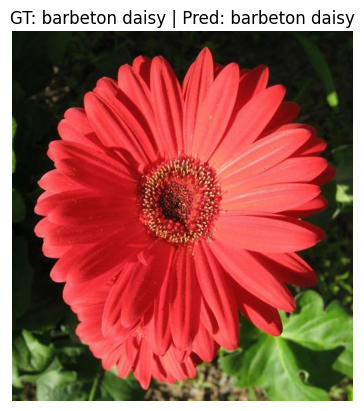

In [11]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in ds_test.take(1):
    img = images.numpy()
    true_label = int(labels.numpy())
    break

# 모델 입력 전처리 동일하게
img_in = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
img_in = tf.cast(img_in, tf.float32)
img_in = preprocess(img_in)
pred = model.predict(tf.expand_dims(img_in, 0), verbose=0)[0]
pred_label = int(np.argmax(pred))

plt.imshow(img)
plt.axis("off")
plt.title(f"GT: {label_names[true_label]} | Pred: {label_names[pred_label]}")
plt.show()


# 추가 분석: 과적합(Generalization), 상세 성능지표, 파라미터/속도 효율, 경량 모델 실험

아래 셀들은 **테스트 정확도만 보는 것에서 한 단계 더** 나아가서,

- train/val curve로 **과적합 확인**
- val/test에 대한 **Top-5, Macro-F1, confusion 분석**
- **파라미터 수 / (가능하면 FLOPs) / 추론 지연시간** 측정
- EfficientNet 변형(B0/B1/B2...) 비교로 **경량 모델 실험** 결과표 만들기

를 위한 코드입니다.


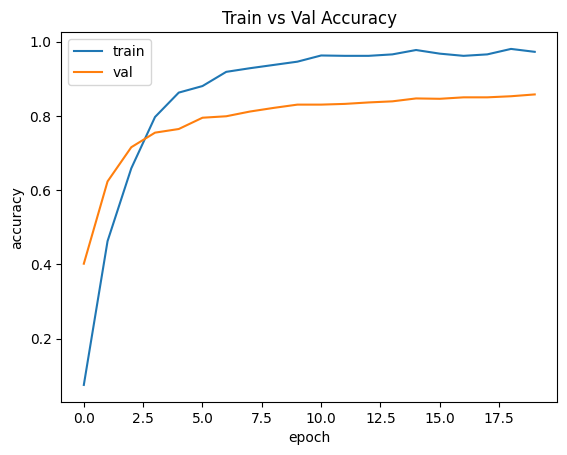

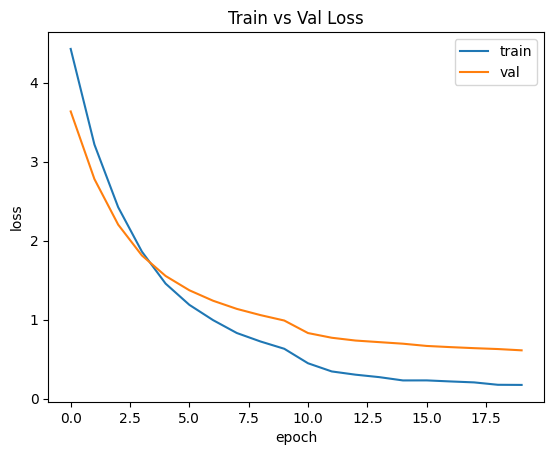

Final train acc: 0.9725
Final  val  acc: 0.8578
Generalization gap (train - val): 0.1147
Final train loss: 0.1753
Final  val  loss: 0.6131


In [12]:

import matplotlib.pyplot as plt

# history1, history2를 이어붙여 "전체 학습 과정"으로 보는 유틸
def concat_hist(h1, h2, key):
    a = h1.history.get(key, [])
    b = h2.history.get(key, [])
    return list(a) + list(b)

def plot_curve(train_values, val_values, ylabel, title):
    plt.figure()
    plt.plot(train_values, label="train")
    plt.plot(val_values, label="val")
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

acc_key = "accuracy"
loss_key = "loss"

train_acc = concat_hist(history1, history2, acc_key)
val_acc   = concat_hist(history1, history2, "val_" + acc_key)
train_loss = concat_hist(history1, history2, loss_key)
val_loss   = concat_hist(history1, history2, "val_" + loss_key)

plot_curve(train_acc, val_acc, "accuracy", "Train vs Val Accuracy")
plot_curve(train_loss, val_loss, "loss", "Train vs Val Loss")

# 간단한 과적합 신호(일반화 갭) 확인
print(f"Final train acc: {train_acc[-1]:.4f}")
print(f"Final  val  acc: {val_acc[-1]:.4f}")
print(f"Generalization gap (train - val): {(train_acc[-1]-val_acc[-1]):.4f}")

print(f"Final train loss: {train_loss[-1]:.4f}")
print(f"Final  val  loss: {val_loss[-1]:.4f}")


In [13]:

# Train/Val/Test를 모두 evaluate 해서 '테스트만 보는 편향' 줄이기
train_loss_eval, train_acc_eval = model.evaluate(train_ds, verbose=0)
val_loss_eval,   val_acc_eval   = model.evaluate(val_ds, verbose=0)
test_loss_eval,  test_acc_eval  = model.evaluate(test_ds, verbose=0)

print(f"Train acc: {train_acc_eval:.4f} | loss: {train_loss_eval:.4f}")
print(f"Val   acc: {val_acc_eval:.4f} | loss: {val_loss_eval:.4f}")
print(f"Test  acc: {test_acc_eval:.4f} | loss: {test_loss_eval:.4f}")


Train acc: 0.9931 | loss: 0.0930
Val   acc: 0.8578 | loss: 0.6131
Test  acc: 0.8323 | loss: 0.6849


In [14]:

import numpy as np
import tensorflow as tf

# (val/test) 예측 확률/라벨 뽑기
def collect_predictions(ds, model):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        y_true.append(yb.numpy())
        y_prob.append(model.predict(xb, verbose=0))
    y_true = np.concatenate(y_true, axis=0)
    y_prob = np.concatenate(y_prob, axis=0)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob

y_true_test, y_pred_test, y_prob_test = collect_predictions(test_ds, model)

# Top-1 / Top-5
top1 = np.mean(y_pred_test == y_true_test)

# Top-5 accuracy 계산 (integer label -> one-hot 필요)
y_true_oh = tf.one_hot(y_true_test, depth=NUM_CLASSES)
top5_metric = tf.keras.metrics.TopKCategoricalAccuracy(k=5)
top5_metric.update_state(y_true_oh, y_prob_test)
top5 = float(top5_metric.result().numpy())

print(f"Top-1 acc (test): {top1:.4f}")
print(f"Top-5 acc (test): {top5:.4f}")

# Macro-F1 (sklearn이 없을 수도 있어서 fallback 포함)
def macro_f1_numpy(y_true, y_pred, num_classes):
    f1s = []
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        precision = tp / (tp + fp + 1e-12)
        recall    = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)
        f1s.append(f1)
    return float(np.mean(f1s))

try:
    from sklearn.metrics import f1_score
    macro_f1 = float(f1_score(y_true_test, y_pred_test, average="macro"))
    print(f"Macro-F1 (test, sklearn): {macro_f1:.4f}")
except Exception as e:
    macro_f1 = macro_f1_numpy(y_true_test, y_pred_test, NUM_CLASSES)
    print(f"Macro-F1 (test, numpy fallback): {macro_f1:.4f}")


Top-1 acc (test): 0.8323
Top-5 acc (test): 0.9478
Macro-F1 (test, sklearn): 0.8227


In [15]:

# Confusion 분석: (102클래스라 전체 heatmap은 보기 어렵고) "가장 많이 헷갈린 쌍"을 뽑아보자
cm = tf.math.confusion_matrix(y_true_test, y_pred_test, num_classes=NUM_CLASSES).numpy()
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

# 가장 많이 헷갈린 Top-N 쌍
N = 12
flat_idx = np.argsort(cm_off.ravel())[::-1]
pairs = np.column_stack(np.unravel_index(flat_idx[:N], cm_off.shape))

print("Most confused label pairs (true -> pred):")
for i, j in pairs:
    if cm_off[i, j] == 0:
        break
    print(f"- {label_names[i]} -> {label_names[j]} : {cm_off[i, j]}")

# 클래스별 정확도(어떤 클래스가 유독 약한지)
per_class_total = cm.sum(axis=1)
per_class_correct = np.diag(cm)
per_class_acc = per_class_correct / np.maximum(per_class_total, 1)

worst_k = 10
worst_idx = np.argsort(per_class_acc)[:worst_k]
print("\nWorst classes by per-class accuracy:")
for idx in worst_idx:
    print(f"- {label_names[idx]} : acc={per_class_acc[idx]:.3f} (n={per_class_total[idx]})")


Most confused label pairs (true -> pred):
- petunia -> hibiscus : 23
- hibiscus -> mallow : 16
- petunia -> pink primrose : 16
- passion flower -> clematis : 15
- petunia -> morning glory : 14
- geranium -> trumpet creeper : 13
- petunia -> balloon flower : 11
- azalea -> clematis : 11
- lotus -> water lily : 11
- camellia -> mallow : 9
- rose -> camellia : 9
- petunia -> tree mallow : 9

Worst classes by per-class accuracy:
- sweet pea : acc=0.250 (n=36)
- snapdragon : acc=0.299 (n=67)
- japanese anemone : acc=0.343 (n=35)
- petunia : acc=0.466 (n=238)
- siam tulip : acc=0.476 (n=21)
- canterbury bells : acc=0.500 (n=20)
- hibiscus : acc=0.523 (n=111)
- columbine : acc=0.530 (n=66)
- azalea : acc=0.566 (n=76)
- desert-rose : acc=0.605 (n=43)


In [16]:

# 파라미터/모델 크기(대략) 측정
total_params = model.count_params()
backbone_params = base.count_params()

print(f"Backbone params: {backbone_params:,}")
print(f"Total model params: {total_params:,}")

# float32 가정 시 파라미터만으로 대략적인 모델 크기 추정 (가중치만)
approx_mb = total_params * 4 / (1024**2)
print(f"Approx weights size (float32): {approx_mb:.2f} MB")


Backbone params: 4,049,571
Total model params: 4,180,233
Approx weights size (float32): 15.95 MB


In [17]:

# (선택) FLOPs 추정: 환경에 따라 동작이 다를 수 있어 try/except로 감쌈
# - FLOPs는 '이론 연산량'이고, 실제 지연시간(latency)은 하드웨어/라이브러리 최적화에 크게 좌우됨
try:
    from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

    def get_flops_approx(keras_model, input_shape=(1, IMG_SIZE, IMG_SIZE, 3)):
        @tf.function
        def forward(x):
            return keras_model(x, training=False)

        concrete = forward.get_concrete_function(tf.TensorSpec(input_shape, tf.float32))
        frozen_func = convert_variables_to_constants_v2(concrete)
        graph_def = frozen_func.graph.as_graph_def()

        with tf.Graph().as_default() as graph:
            tf.graph_util.import_graph_def(graph_def, name="")
            run_meta = tf.compat.v1.RunMetadata()
            opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
            flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
        return flops.total_float_ops

    flops = get_flops_approx(model)
    print(f"Approx FLOPs (batch=1): {flops:,}")
except Exception as e:
    print("FLOPs estimation skipped / failed:", e)


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Approx FLOPs (batch=1): 801,046,907


In [18]:

# 추론 지연시간(latency) 간단 벤치마크 (환경에 따라 값이 달라질 수 있음)
import time

xb, yb = next(iter(test_ds.take(1)))
# warm-up
for _ in range(5):
    _ = model(xb, training=False)

iters = 30
t0 = time.perf_counter()
for _ in range(iters):
    _ = model(xb, training=False)
t1 = time.perf_counter()

batch_sec = (t1 - t0) / iters
per_image_ms = batch_sec / xb.shape[0] * 1000

print(f"Batch latency (sec): {batch_sec:.6f}")
print(f"Per-image latency (ms): {per_image_ms:.3f}  | batch_size={xb.shape[0]}")


Batch latency (sec): 0.266400
Per-image latency (ms): 8.325  | batch_size=32


## 경량 모델 실험: EfficientNet 변형 비교(B0/B1/B2...)

- 아래 코드는 **동일한 데이터셋**에서 EfficientNet variant를 바꿔가며
  - val/test 성능
  - 파라미터 수
  - 추론 지연시간
  을 테이블로 모아 **성능 대비 효율(Pareto)** 을 보이게 해줍니다.

> 주의: variant마다 권장 입력 해상도가 다르지만, 여기서는 비교를 단순화하려고 **현재 파이프라인(IMG_SIZE=224)** 을 그대로 사용합니다.  
> (발표에서 “해상도까지 포함한 compound scaling 비교를 하려면 variant별 IMG_SIZE를 바꿔야 한다” 라고 코멘트하면 매우 프로처럼 들림)


In [19]:

import pandas as pd
import numpy as np
import tensorflow as tf
import time

EFFNET = {
    "B0": tf.keras.applications.EfficientNetB0,
    "B1": tf.keras.applications.EfficientNetB1,
    "B2": tf.keras.applications.EfficientNetB2,
    "B3": tf.keras.applications.EfficientNetB3,
}

def build_effnet_classifier(variant="B0", dropout=0.3, lr=1e-3):
    Base = EFFNET[variant]
    backbone = Base(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    backbone.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    m = tf.keras.Model(inputs, outputs)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return m, backbone

def benchmark_latency(model, dataset, warmup=3, iters=15):
    xb, _ = next(iter(dataset.take(1)))
    for _ in range(warmup):
        _ = model(xb, training=False)
    t0 = time.perf_counter()
    for _ in range(iters):
        _ = model(xb, training=False)
    t1 = time.perf_counter()
    batch_sec = (t1 - t0) / iters
    return float(batch_sec / xb.shape[0] * 1000)  # ms / image

results = []
variants = ["B0", "B1", "B2"]

for v in variants:
    print(f"\n=== Variant {v} ===")
    m, bb = build_effnet_classifier(v, dropout=0.3, lr=1e-3)

    # 빠른 비교용: head만 짧게 학습 (발표용이라면 epochs를 3~5로 시작)
    h = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=3,
        verbose=2
    )

    val_loss, val_acc = m.evaluate(val_ds, verbose=0)
    test_loss, test_acc = m.evaluate(test_ds, verbose=0)
    params = m.count_params()
    per_image_ms = benchmark_latency(m, test_ds)

    results.append({
        "variant": v,
        "val_acc": float(val_acc),
        "test_acc": float(test_acc),
        "params": int(params),
        "ms_per_image": float(per_image_ms),
        "acc_per_Mparams": float(val_acc) / (params / 1e6)
    })

df_eff = pd.DataFrame(results).sort_values("val_acc", ascending=False)
df_eff



=== Variant B0 ===
Epoch 1/3
32/32 - 54s - 2s/step - accuracy: 0.0598 - loss: 4.4926 - val_accuracy: 0.2853 - val_loss: 3.7568
Epoch 2/3
32/32 - 14s - 428ms/step - accuracy: 0.4382 - loss: 3.2587 - val_accuracy: 0.5794 - val_loss: 2.8749
Epoch 3/3
32/32 - 20s - 617ms/step - accuracy: 0.6735 - loss: 2.4315 - val_accuracy: 0.6873 - val_loss: 2.2860

=== Variant B1 ===
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
32/32 - 78s - 2s/step - accuracy: 0.0627 - loss: 4.4554 - val_accuracy: 0.3343 - val_loss: 3.6640
Epoch 2/3
32/32 - 15s - 454ms/step - accuracy: 0.4265 - loss: 3.2270 - val_accuracy: 0.6245 - val_loss: 2.8170
Epoch 3/3
32/32 - 14s - 433ms/step - accuracy: 0.6510 - loss: 2.4500 - val_accuracy: 0.7118 - val_loss: 2.2304

=== Variant B2 ===
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
32/32 - 83s - 3s/step - accuracy: 0.0588 - loss: 4.4127 - val_accuracy: 0.3667 - val_loss: 3.6730
Epoch 2/3
32/32 - 15s - 461ms/step - accuracy: 0.4637 - loss: 3.2415 -

,variant,val_acc,test_acc,params,ms_per_image,acc_per_Mparams
1,B1,0.711765,0.679297,6705901,12.735525,0.106140
2,B2,0.700000,0.659619,7912287,11.975868,0.088470
0,B0,0.687255,0.655228,4180233,9.760399,0.164406


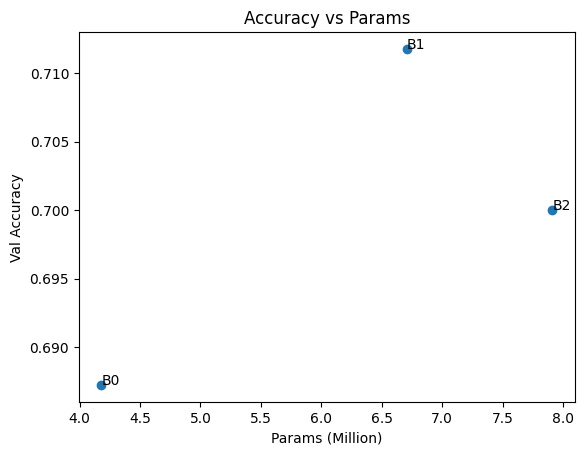

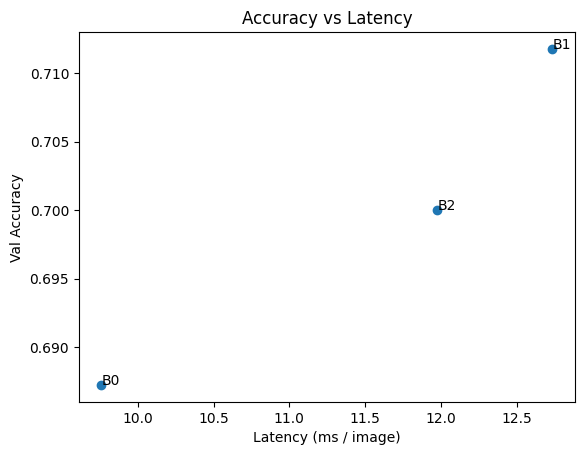

,variant,val_acc,test_acc,params,ms_per_image,acc_per_Mparams
1,B1,0.711765,0.679297,6705901,12.735525,0.106140
2,B2,0.700000,0.659619,7912287,11.975868,0.088470
0,B0,0.687255,0.655228,4180233,9.760399,0.164406


In [20]:

# 효율 시각화: val_acc vs params / val_acc vs latency
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_eff["params"]/1e6, df_eff["val_acc"])
for _, r in df_eff.iterrows():
    plt.text(r["params"]/1e6, r["val_acc"], r["variant"])
plt.xlabel("Params (Million)")
plt.ylabel("Val Accuracy")
plt.title("Accuracy vs Params")
plt.show()

plt.figure()
plt.scatter(df_eff["ms_per_image"], df_eff["val_acc"])
for _, r in df_eff.iterrows():
    plt.text(r["ms_per_image"], r["val_acc"], r["variant"])
plt.xlabel("Latency (ms / image)")
plt.ylabel("Val Accuracy")
plt.title("Accuracy vs Latency")
plt.show()

df_eff.sort_values(["val_acc","ms_per_image"], ascending=[False, True])
